# Open-Set WiFi Gait Authentication via Supervised Contrastive Learning

ECE 228 | Machine Learning for Physical Applications | Project Codebase

Soham Guha Mazumder and Afreen Haider


---

### Project Overview

This notebook implements a **passive, device-free gait authentication system** built on WiFi Channel State Information (CSI). A person walking through a WiFi link perturbs the multipath channel in a gait-specific way; we capture this as a 64×64 Doppler-time spectrogram and train a metric-learning CNN (GaitNet) to embed each spectrogram onto a 128-dimensional unit hypersphere. At inference time, an unknown query is accepted or rejected based on its nearest-neighbour distance to a pre-enrolled gallery.

The system operates in an **open-set** regime: it must accept 20 registered users *and* reject 5 completely unseen intruders who were never shown during training.

**Dataset:** WiStride dataset has 25 participants, static indoor corridor, 40 walks each (~975 spectrograms total).

---



In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ece228_project/csi_dataset/

import os, random, pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

#Parameters to tweak
SEED           = 42
EMBEDDING_DIM  = 128
TEMPERATURE    = 0.1    #SupCon temperature (higher --> more aggressive training)
N_PER_CLASS    = 6      #samples per class per balanced batch (20 × 6 = 120 per batch)
N_ITERS        = 10     #balanced batches per epoch
EPOCHS         = 400
LR             = 5e-4
N_REGISTERED   = 20     #20 registered users to be used for training
DRIVE_NPZ      = '/content/drive/MyDrive/ece228_project/csi_dataset/spectrograms1.npz'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

USER_NAMES = {lbl: f'Participant_{lbl + 1:02d}' for lbl in range(25)}

print(f'Device         : {DEVICE}')
print(f'Embedding dim  : {EMBEDDING_DIM}')
print(f'Batch size     : {N_REGISTERED} classes × {N_PER_CLASS} samples = {N_REGISTERED * N_PER_CLASS} per step')
print(f'Positive pairs : {N_REGISTERED} × C({N_PER_CLASS},2) = {N_REGISTERED * N_PER_CLASS * (N_PER_CLASS - 1) // 2} per batch  (vs ~8 for triplet)')

Mounted at /content/drive
/content/drive/MyDrive/ece228_project/csi_dataset
Device         : cuda
Embedding dim  : 128
Batch size     : 20 classes × 6 samples = 120 per step
Positive pairs : 20 × C(6,2) = 300 per batch  (vs ~8 for triplet)


In [2]:
#load dataset
with np.load(DRIVE_NPZ) as data:
    raw_specs  = data['spectrograms'].astype(np.float32)
    raw_labels = data['labels'].astype(np.int64)

raw_specs = raw_specs[:, np.newaxis, :, :]   # (975, 1, 64, 64)

print(f'Spectrograms: {raw_specs.shape}  dtype={raw_specs.dtype}')
print(f'Pixel range : [{raw_specs.min():.2f}, {raw_specs.max():.2f}]  (z-scored, no extra normalisation needed)')
print()
for lbl in range(25):
    n   = int(np.sum(raw_labels == lbl))
    tag = 'registered' if lbl < N_REGISTERED else 'INTRUDER'
    print(f'  {USER_NAMES[lbl]:20s} (label {lbl:2d}): {n:3d} walks  [{tag}]')

Spectrograms: (975, 1, 64, 64)  dtype=float32
Pixel range : [-7.50, 3.50]  (z-scored, no extra normalisation needed)

  Participant_01       (label  0):  40 walks  [registered]
  Participant_02       (label  1):  38 walks  [registered]
  Participant_03       (label  2):  39 walks  [registered]
  Participant_04       (label  3):  40 walks  [registered]
  Participant_05       (label  4):  40 walks  [registered]
  Participant_06       (label  5):  36 walks  [registered]
  Participant_07       (label  6):  40 walks  [registered]
  Participant_08       (label  7):  40 walks  [registered]
  Participant_09       (label  8):  40 walks  [registered]
  Participant_10       (label  9):  39 walks  [registered]
  Participant_11       (label 10):  40 walks  [registered]
  Participant_12       (label 11):  40 walks  [registered]
  Participant_13       (label 12):  40 walks  [registered]
  Participant_14       (label 13):  40 walks  [registered]
  Participant_15       (label 14):  39 walks  [registere

In [3]:
# 70 / 15 / 15 split by walk number in chronological order
train_imgs_l, train_lbls_l              = [], []
gallery_imgs_l, gallery_lbls_l          = [], []
test_auth_imgs_l, test_auth_lbls_l      = [], []
test_intruder_imgs_l, test_intruder_lbls_l = [], []

for lbl in range(25):
    idx        = np.where(raw_labels == lbl)[0]
    sorted_idx = idx[np.argsort(raw_walks[idx])]
    n          = len(sorted_idx)

    if lbl < N_REGISTERED:
        n_train   = int(n * 0.70)
        n_gallery = max(1, int(n * 0.15))
        n_test    = n - n_train - n_gallery
        train_imgs_l.append(raw_specs[sorted_idx[:n_train]])
        train_lbls_l.append(np.full(n_train,   lbl, dtype=np.int64))
        gallery_imgs_l.append(raw_specs[sorted_idx[n_train:n_train + n_gallery]])
        gallery_lbls_l.append(np.full(n_gallery, lbl, dtype=np.int64))
        test_auth_imgs_l.append(raw_specs[sorted_idx[n_train + n_gallery:]])
        test_auth_lbls_l.append(np.full(n_test,  lbl, dtype=np.int64))
    else:
        test_intruder_imgs_l.append(raw_specs[sorted_idx])
        test_intruder_lbls_l.append(np.full(n, lbl, dtype=np.int64))

train_imgs         = np.concatenate(train_imgs_l)
train_lbls         = np.concatenate(train_lbls_l)
gallery_imgs       = np.concatenate(gallery_imgs_l)
gallery_lbls       = np.concatenate(gallery_lbls_l)
test_auth_imgs     = np.concatenate(test_auth_imgs_l)
test_auth_lbls     = np.concatenate(test_auth_lbls_l)
test_intruder_imgs = np.concatenate(test_intruder_imgs_l)
test_intruder_lbls = np.concatenate(test_intruder_lbls_l)

counts = np.bincount(train_lbls, minlength=N_REGISTERED)
print(f'Train    : {len(train_imgs):4d}  |  Gallery: {len(gallery_imgs):3d}  |  Test-auth: {len(test_auth_imgs):3d}  |  Intruders: {len(test_intruder_imgs)}')
print(f'Train per user: min={counts.min()}  max={counts.max()}  avg={counts.mean():.1f}')

Train    :  541  |  Gallery: 112  |  Test-auth: 125  |  Intruders: 197
Train per user: min=24  max=28  avg=27.1


In [4]:
#Building the Gaitnet to augment images and the balanced batch sampler

class GaitDataset(Dataset):
    """Returns (augmented_image, label). Augmentation: time-axis flip + Gaussian noise."""
    def __init__(self, images, labels, augment=True):
        self.images  = images
        self.labels  = labels
        self.augment = augment

    def _augment(self, img):
        if np.random.rand() > 0.5:
            img = img[:, :, ::-1].copy()   # flip time axis (AB ↔ BA direction)
        img = img + np.random.randn(*img.shape).astype(np.float32) * 0.05
        return img

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].copy()
        if self.augment:
            img = self._augment(img)
        return torch.tensor(img), torch.tensor(int(self.labels[idx]), dtype=torch.long)



class BalancedBatchSampler(torch.utils.data.BatchSampler):
    """Yields balanced batches: every class appears exactly n_per_class times per batch."""
    def __init__(self, labels, n_per_class=N_PER_CLASS, n_iters=N_ITERS):
        self.labels           = np.array(labels)
        self.unique_labels    = np.unique(self.labels).tolist()
        self.n_per_class      = n_per_class
        self.n_iters          = n_iters
        self.label_to_indices = {
            int(l): np.where(self.labels == l)[0].tolist()
            for l in self.unique_labels
        }

    def __iter__(self):
        for _ in range(self.n_iters):
            batch = []
            for lbl in self.unique_labels:
                pool = self.label_to_indices[int(lbl)]
                batch.extend(random.choices(pool, k=self.n_per_class))  # with replacement if needed
            random.shuffle(batch)
            yield batch

    def __len__(self):
        return self.n_iters


train_dataset = GaitDataset(train_imgs, train_lbls, augment=True)
batch_sampler = BalancedBatchSampler(train_lbls)
train_loader  = DataLoader(train_dataset, batch_sampler=batch_sampler,
                            num_workers=2, pin_memory=True)

print(f'Train dataset  : {len(train_dataset)} samples')
print(f'Batch size     : {len(batch_sampler.unique_labels) * N_PER_CLASS} ({len(batch_sampler.unique_labels)} classes × {N_PER_CLASS} each)')
print(f'Batches/epoch  : {N_ITERS}')
print(f'Positive pairs/batch: {len(batch_sampler.unique_labels) * N_PER_CLASS * (N_PER_CLASS - 1) // 2}')

Train dataset  : 541 samples
Batch size     : 120 (20 classes × 6 each)
Batches/epoch  : 10
Positive pairs/batch: 300


In [5]:
#Supervised Contrastive Loss Model


class SupConLoss(nn.Module):
    def __init__(self, temperature=TEMPERATURE):
        super().__init__()
        self.T = temperature

    def forward(self, feats, labels):
        """feats: (N, D) L2-normalised | labels: (N,) int"""
        device = feats.device
        N      = feats.shape[0]

        # All-pairs cosine similarity (dot product of unit vectors)
        sim = torch.matmul(feats, feats.T) / self.T   # (N,N)

        # Positive mask: same class, excluding self-pairs
        lbl_col  = labels.unsqueeze(1)
        pos_mask = (lbl_col == lbl_col.T).float()
        eye      = torch.eye(N, dtype=torch.float, device=device)
        pos_mask = pos_mask - eye    # exclude self

        if pos_mask.sum() == 0:
            return feats.sum() * 0.0   # no positives in batch; return 0 with grad attached

        # Numerically stable: subtract row-max before exp
        sim_max, _ = sim.max(dim=1, keepdim=True)
        sim        = sim - sim_max.detach()

        exp_sim = torch.exp(sim)

        # Denominator: sum over all k ≠ i
        denom    = (exp_sim * (1.0 - eye)).sum(dim=1, keepdim=True).clamp(min=1e-8)
        log_prob = sim - torch.log(denom)   # (N,N)

        # Mean log-prob over positives, then over anchors that have a positive
        n_pos = pos_mask.sum(dim=1).clamp(min=1)
        loss  = -(log_prob * pos_mask).sum(dim=1) / n_pos

        valid = pos_mask.sum(dim=1) > 0
        return loss[valid].mean()


#GaitNet Model - converts to 128-dim embeddings

class GaitNet(nn.Module):
    """Input: (B,1,64,64).  Output: (B, EMBEDDING_DIM) unit-norm embedding."""
    def __init__(self, emb_dim=EMBEDDING_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,   32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(256, emb_dim),
        )

    def forward(self, x):
        return F.normalize(self.head(self.encoder(x)), p=2, dim=1)


criterion = SupConLoss(temperature=TEMPERATURE)
model     = GaitNet(emb_dim=EMBEDDING_DIM).to(DEVICE)
n_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'GaitNet: {n_params:,} parameters  |  emb_dim={EMBEDDING_DIM}  |  temperature={TEMPERATURE}')

GaitNet: 487,488 parameters  |  emb_dim=128  |  temperature=0.1


Training 400 epochs | LR=0.0005 | SupCon temperature=0.1
Positive pairs per batch: 300
Epoch [ 20/400]  SupCon loss=3.9723  lr=4.97e-04
Epoch [ 40/400]  SupCon loss=3.5382  lr=4.88e-04
Epoch [ 60/400]  SupCon loss=3.4545  lr=4.73e-04
Epoch [ 80/400]  SupCon loss=3.1263  lr=4.52e-04
Epoch [100/400]  SupCon loss=2.9164  lr=4.27e-04
Epoch [120/400]  SupCon loss=2.6941  lr=3.97e-04
Epoch [140/400]  SupCon loss=2.5712  lr=3.63e-04
Epoch [160/400]  SupCon loss=2.4486  lr=3.27e-04
Epoch [180/400]  SupCon loss=2.3230  lr=2.89e-04
Epoch [200/400]  SupCon loss=2.2176  lr=2.50e-04
Epoch [220/400]  SupCon loss=2.1575  lr=2.11e-04
Epoch [240/400]  SupCon loss=2.0871  lr=1.73e-04
Epoch [260/400]  SupCon loss=2.0502  lr=1.37e-04
Epoch [280/400]  SupCon loss=1.9821  lr=1.03e-04
Epoch [300/400]  SupCon loss=1.9583  lr=7.32e-05
Epoch [320/400]  SupCon loss=1.9341  lr=4.77e-05
Epoch [340/400]  SupCon loss=1.9379  lr=2.72e-05
Epoch [360/400]  SupCon loss=1.9419  lr=1.22e-05
Epoch [380/400]  SupCon loss=1.

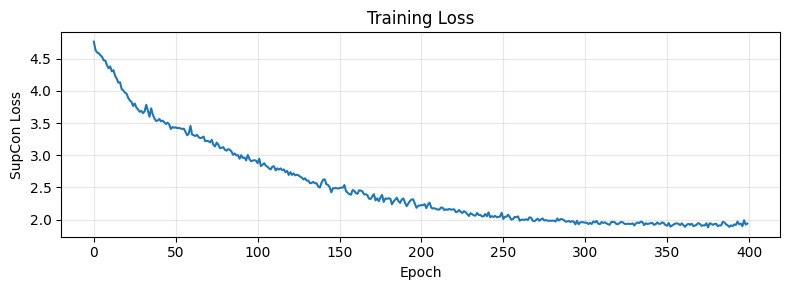

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f'Training {EPOCHS} epochs | LR={LR} | SupCon temperature={TEMPERATURE}')
print(f'Positive pairs per batch: {N_REGISTERED * N_PER_CLASS * (N_PER_CLASS - 1) // 2}')
print('=' * 60)

loss_history = []
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for imgs, lbls in train_loader:
        imgs = imgs.to(DEVICE)
        lbls = lbls.to(DEVICE)

        embs = model(imgs)
        loss = criterion(embs, lbls)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1:3d}/{EPOCHS}]  SupCon loss={avg_loss:.4f}  lr={lr_now:.2e}')

os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/gait_net_v3.pth')
print('\nModel saved → models/gait_net_v3.pth')

plt.figure(figsize=(8, 3))
plt.plot(loss_history)
plt.xlabel('Epoch'); plt.ylabel('SupCon Loss'); plt.title('Training Loss')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

Computing training embeddings for quality check...
Training pairwise distances:
  Same-person pairs :   7066  mean=0.0720  std=0.0492
  Diff-person pairs : 139004  mean=1.4113  std=0.3007
  Separation Δ      : 1.3393  (v2 had 0.14 — needs to be much larger now)


/tmp/ipykernel_1037/412588362.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', N_REGISTERED)


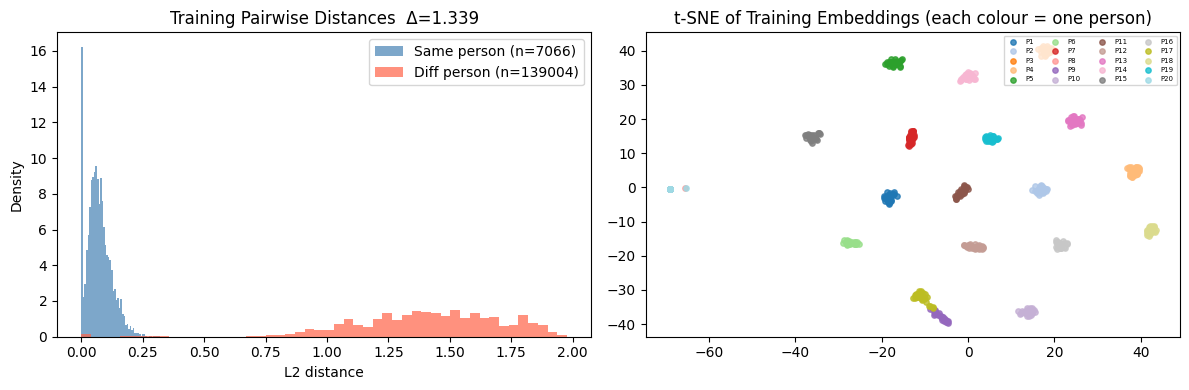

In [7]:
#Embedding quality diagnostic
#Computing pairwise distances on the training set to verify the embedding space
#has actually learned to separate people before running gallery enrollment.

def embed_batch(images, bs=128):
    model.eval()
    parts = []
    with torch.no_grad():
        for start in range(0, len(images), bs):
            batch = torch.tensor(images[start:start + bs]).to(DEVICE)
            parts.append(model(batch).cpu().numpy())
    return np.concatenate(parts)


print('Computing training embeddings for quality check...')
train_embs = embed_batch(train_imgs)   # (N_train,D)

# All pairwise distances (upper triangle)
N    = len(train_embs)
rows, cols = np.triu_indices(N, k=1)

# Vectorised L2 — avoid materialising full N×N matrix
CHUNK = 100
same_d, diff_d = [], []
for start in range(0, len(rows), 50000):
    r = rows[start:start+50000]
    c = cols[start:start+50000]
    d = np.linalg.norm(train_embs[r] - train_embs[c], axis=1)
    mask_same = (train_lbls[r] == train_lbls[c])
    same_d.append(d[mask_same])
    diff_d.append(d[~mask_same])

same_d = np.concatenate(same_d)
diff_d = np.concatenate(diff_d)

print(f'Training pairwise distances:')
print(f'  Same-person pairs : {len(same_d):6d}  mean={same_d.mean():.4f}  std={same_d.std():.4f}')
print(f'  Diff-person pairs : {len(diff_d):6d}  mean={diff_d.mean():.4f}  std={diff_d.std():.4f}')
separation = diff_d.mean() - same_d.mean()
print(f'  Separation Δ      : {separation:.4f}  (v2 had 0.14 — needs to be much larger now)')

if separation < 0.15:
    print('\n  WARNING: embedding space still not well separated.')
    print('  Try re-running with more epochs or lower temperature.')

# Visualise
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(same_d, bins=50, alpha=0.7, color='steelblue', density=True, label=f'Same person (n={len(same_d)})')
ax[0].hist(diff_d, bins=50, alpha=0.7, color='tomato',    density=True, label=f'Diff person (n={len(diff_d)})')
ax[0].set_xlabel('L2 distance'); ax[0].set_ylabel('Density')
ax[0].set_title(f'Training Pairwise Distances  Δ={separation:.3f}')
ax[0].legend()

# t-SNE to view the training user clusters
try:
    from sklearn.manifold import TSNE
    tsne_emb = TSNE(n_components=2, random_state=SEED, perplexity=20).fit_transform(train_embs)
    cmap = plt.cm.get_cmap('tab20', N_REGISTERED)
    for lbl in range(N_REGISTERED):
        mask = (train_lbls == lbl)
        ax[1].scatter(tsne_emb[mask, 0], tsne_emb[mask, 1], c=[cmap(lbl)],
                       label=f'P{lbl+1}', s=15, alpha=0.8)
    ax[1].set_title('t-SNE of Training Embeddings (each colour = one person)')
    ax[1].legend(fontsize=5, ncol=4, loc='upper right')
except ImportError:
    ax[1].text(0.5, 0.5, 'sklearn not available for t-SNE', ha='center', va='center', transform=ax[1].transAxes)

plt.tight_layout(); plt.show()

In [8]:
#KNN Gallery enrollment and Expanded Gallery
#Original gallery has 112 points. After training is complete the training embeddings are stable, so we can safely
#add them to the gallery. This gives around 34 points per user instead of 6, covering
#a much larger region of each user's embedding space so correct correlations have a higher chance of being detected.
#
#We keep gallery_emb_arr_orig (112 pts) separately for threshold calibration
#in the next cell. This is because the threshold should be calibrated on the same temporal
#regime as the test data (walks 29-33 ≈ walks 34-40) and not on training walks.

model.eval()
gallery_emb_list, gallery_lbl_list = [], []

with torch.no_grad():
    for start in range(0, len(gallery_imgs), 128):
        batch = torch.tensor(gallery_imgs[start:start + 128]).to(DEVICE)
        gallery_emb_list.append(model(batch).cpu().numpy())
        gallery_lbl_list.append(gallery_lbls[start:start + 128])

# Original 112-point gallery for kept for threshold calibration
gallery_emb_arr_orig = np.concatenate(gallery_emb_list)   # (112,D)
gallery_lbl_arr_orig = np.concatenate(gallery_lbl_list)   # (112,)

#train_embs was computed in the diagnostic cell above (embed_batch(train_imgs))
#Combining both galleries
gallery_emb_arr = np.concatenate([train_embs, gallery_emb_arr_orig])   # (~653,D)
gallery_lbl_arr = np.concatenate([train_lbls,  gallery_lbl_arr_orig])   # (~653,)

counts_per_user = np.array([
    int((gallery_lbl_arr == lbl).sum()) for lbl in range(N_REGISTERED)
])
print(f'Original gallery : {len(gallery_emb_arr_orig)} embeddings  '
      f'({len(gallery_emb_arr_orig) // N_REGISTERED} per user)')
print(f'Expanded gallery : {len(gallery_emb_arr)} embeddings  '
      f'(min={counts_per_user.min()}  max={counts_per_user.max()}  '
      f'avg={counts_per_user.mean():.1f} per user)')
print(f'  → 1-NN search now has ~{counts_per_user.mean():.0f}x more candidates per user')

with open('models/gallery_knn_v3.pkl', 'wb') as f:
    pickle.dump({
        'embs':        gallery_emb_arr,
        'labels':      gallery_lbl_arr,
        'embs_orig':   gallery_emb_arr_orig,
        'labels_orig': gallery_lbl_arr_orig,
        'user_names':  USER_NAMES,
    }, f)
print('Gallery saved → models/gallery_knn_v3.pkl')

Original gallery : 112 embeddings  (5 per user)
Expanded gallery : 653 embeddings  (min=29  max=34  avg=32.6 per user)
  → 1-NN search now has ~33x more candidates per user
Gallery saved → models/gallery_knn_v3.pkl


Leave-one-CLASS-out 1-NN calibration:
  Genuine  (own training present) : n=112  mean=0.1965  std=0.1743
  Impostor (own training absent)  : n=112  mean=0.2633  std=0.2719
  Separation Δ : 0.0668  (positive = correct direction)

Calibrated threshold (leave-one-class-out 1-NN EER):
  EER threshold     : 0.1918
  Calibration EER   : 46.43%
  Threshold @10%FRR : 0.4087


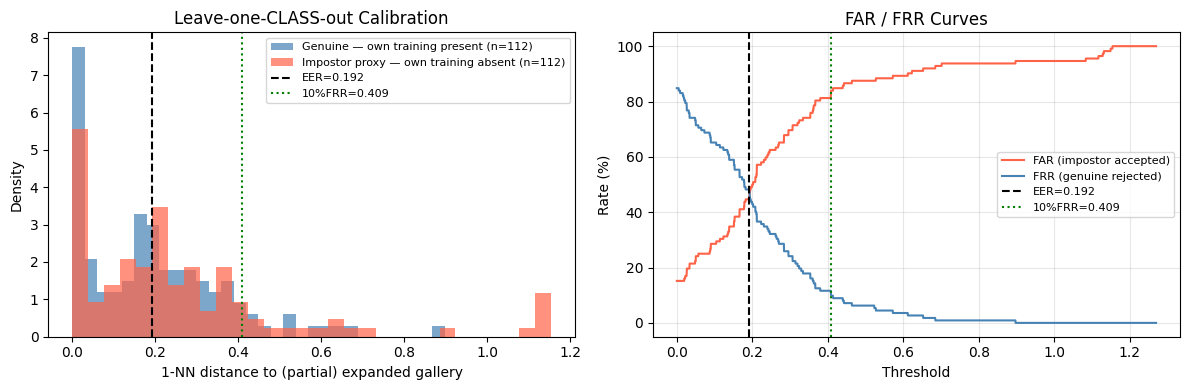

In [9]:
#Threshold calibration: leave-one-CLASS-out 1-NN

# We use the scenarios that happen at auth time to find the threshold
# Make two calculations for every point in the orignal gallery

#  GENUINE: user queries against gallery that INCLUDES their own training data.
#              1-NN distance = overall nearest excluding its own self.
#              If own training is nearby then distance will be small (should be ACCEPTED).
#
#  IMPOSTOR proxy: loop through all gallery points, WITHOUT including all its own user-class data in the expanded gallery
#              This simulates an intruder whose gait was never enrolled.
#              1-NN distance = nearest point from any OTHER user.
#              Should be LARGER than genuine since there is no matching anchor
#
#   Separation = impostor_mean - genuine_mean > 0

n_train_pts = len(train_embs)   # 541 — index offset of gallery_orig in expanded array

genuine_1nn  = []   #1-NN dist when user's own training IS present (auth scenario)
impostor_1nn = []   #1-NN dist when user's own training is ABSENT (intruder proxy)

for i in range(len(gallery_emb_arr_orig)):
    query_emb = gallery_emb_arr_orig[i]
    query_lbl = int(gallery_lbl_arr_orig[i])

    dists = np.linalg.norm(gallery_emb_arr - query_emb, axis=1)   # (653,)

    # GENUINE: exclude only self but user's training data stays in gallery
    genuine_dists = dists.copy()
    genuine_dists[n_train_pts + i] = np.inf
    genuine_1nn.append(float(np.min(genuine_dists)))

    # IMPOSTOR PROXY: exclude every point of this user's class
    all_user_mask = (gallery_lbl_arr == query_lbl)
    impostor_dists = dists.copy()
    impostor_dists[all_user_mask] = np.inf
    impostor_1nn.append(float(np.min(impostor_dists)))

genuine_1nn  = np.array(genuine_1nn)
impostor_1nn = np.array(impostor_1nn)

sep_cal = impostor_1nn.mean() - genuine_1nn.mean()
print('Leave-one-CLASS-out 1-NN calibration:')
print(f'  Genuine  (own training present) : n={len(genuine_1nn)}  '
      f'mean={genuine_1nn.mean():.4f}  std={genuine_1nn.std():.4f}')
print(f'  Impostor (own training absent)  : n={len(impostor_1nn)}  '
      f'mean={impostor_1nn.mean():.4f}  std={impostor_1nn.std():.4f}')
print(f'  Separation Δ : {sep_cal:.4f}  (positive = correct direction)')

# EER calibration
t_max      = max(impostor_1nn.max(), genuine_1nn.max()) * 1.1
thresholds = np.linspace(0.0, t_max, 3000)
far_arr    = np.array([np.mean(impostor_1nn <= t) for t in thresholds])   # impostor accepted
frr_arr    = np.array([np.mean(genuine_1nn  >  t) for t in thresholds])   # genuine rejected

eer_idx   = int(np.argmin(np.abs(far_arr - frr_arr)))
THRESHOLD = float(thresholds[eer_idx])
cal_eer   = float((far_arr[eer_idx] + frr_arr[eer_idx]) / 2)

frr10_cands     = np.where(frr_arr <= 0.10)[0]
THRESHOLD_10FRR = float(thresholds[frr10_cands[0]]) if len(frr10_cands) else THRESHOLD

print(f'\nCalibrated threshold (leave-one-class-out 1-NN EER):')
print(f'  EER threshold     : {THRESHOLD:.4f}')
print(f'  Calibration EER   : {cal_eer * 100:.2f}%')
print(f'  Threshold @10%FRR : {THRESHOLD_10FRR:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(genuine_1nn,  bins=30, alpha=0.7, color='steelblue', density=True,
             label=f'Genuine — own training present (n={len(genuine_1nn)})')
axes[0].hist(impostor_1nn, bins=30, alpha=0.7, color='tomato',    density=True,
             label=f'Impostor proxy — own training absent (n={len(impostor_1nn)})')
axes[0].axvline(THRESHOLD,       color='black', linestyle='--', label=f'EER={THRESHOLD:.3f}')
axes[0].axvline(THRESHOLD_10FRR, color='green', linestyle=':',  label=f'10%FRR={THRESHOLD_10FRR:.3f}')
axes[0].set_xlabel('1-NN distance to (partial) expanded gallery')
axes[0].set_ylabel('Density')
axes[0].set_title('Leave-one-CLASS-out Calibration')
axes[0].legend(fontsize=8)

axes[1].plot(thresholds, far_arr * 100, color='tomato',    linewidth=1.5, label='FAR (impostor accepted)')
axes[1].plot(thresholds, frr_arr * 100, color='steelblue', linewidth=1.5, label='FRR (genuine rejected)')
axes[1].axvline(THRESHOLD,       color='black', linestyle='--', linewidth=1.5, label=f'EER={THRESHOLD:.3f}')
axes[1].axvline(THRESHOLD_10FRR, color='green', linestyle=':',  linewidth=1.5, label=f'10%FRR={THRESHOLD_10FRR:.3f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Rate (%)')
axes[1].set_title('FAR / FRR Curves')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [10]:
#Evaluation: identification + rejection

def identify(emb, threshold=THRESHOLD):
    """1-NN search across KNN gallery. Returns (label, name, distance, status)."""
    dists       = np.linalg.norm(gallery_emb_arr - emb, axis=1)
    nearest_idx = int(np.argmin(dists))
    min_dist    = float(dists[nearest_idx])
    matched_lbl = int(gallery_lbl_arr[nearest_idx])
    if min_dist <= threshold:
        return matched_lbl, USER_NAMES[matched_lbl], min_dist, 'ACCEPTED'
    return None, 'Unknown (Intruder)', min_dist, 'REJECTED'


def evaluate_at_threshold(auth_dists, intruder_dists, auth_lbls, auth_results, threshold, label=''):
    decisions_auth     = ['ACCEPTED' if d <= threshold else 'REJECTED' for d in auth_dists]
    decisions_intruder = ['ACCEPTED' if d <= threshold else 'REJECTED' for d in intruder_dists]

    correct_id = sum(1 for (r_lbl, _, _, st), true_lbl
                     in zip(auth_results, auth_lbls)
                     if st == 'ACCEPTED' and r_lbl == true_lbl)
    accepted   = decisions_auth.count('ACCEPTED')
    rejected_i = decisions_intruder.count('REJECTED')

    print(f'\n{label} (threshold={threshold:.4f})')
    print(f'  Correctly identified (right name): {correct_id}/{len(auth_dists)}  ({correct_id/len(auth_dists)*100:.1f}%)')
    print(f'  Auth acceptance rate             : {accepted}/{len(auth_dists)}  ({accepted/len(auth_dists)*100:.1f}%)')
    print(f'  Intruder rejection rate          : {rejected_i}/{len(intruder_dists)}  ({rejected_i/len(intruder_dists)*100:.1f}%)')
    return correct_id, accepted, rejected_i


print('Computing test embeddings...')
auth_embs     = embed_batch(test_auth_imgs)
intruder_embs = embed_batch(test_intruder_imgs)

auth_results     = [identify(e) for e in auth_embs]
intruder_results = [identify(e) for e in intruder_embs]

auth_dists_test     = np.array([r[2] for r in auth_results])
intruder_dists_test = np.array([r[2] for r in intruder_results])

print(f'\nTest distance stats:')
print(f'  Auth users : mean={auth_dists_test.mean():.4f}  std={auth_dists_test.std():.4f}')
print(f'  Intruders  : mean={intruder_dists_test.mean():.4f}  std={intruder_dists_test.std():.4f}')
print(f'  Separation : {intruder_dists_test.mean() - auth_dists_test.mean():.4f}  (must be positive)')

print(f'\n{"="*60}')

# Report at two operating points
cid_eer, acc_eer, rej_eer = evaluate_at_threshold(
    auth_dists_test, intruder_dists_test, test_auth_lbls, auth_results,
    threshold=THRESHOLD, label='EER threshold')

cid_10, acc_10, rej_10 = evaluate_at_threshold(
    auth_dists_test, intruder_dists_test, test_auth_lbls,
    [identify(e, threshold=THRESHOLD_10FRR) for e in auth_embs],
    threshold=THRESHOLD_10FRR, label='10% FRR threshold (tighter security)')

Computing test embeddings...

Test distance stats:
  Auth users : mean=0.1934  std=0.1653
  Intruders  : mean=0.1972  std=0.1628
  Separation : 0.0038  (must be positive)


EER threshold (threshold=0.1918)
  Correctly identified (right name): 11/125  (8.8%)
  Auth acceptance rate             : 66/125  (52.8%)
  Intruder rejection rate          : 92/197  (46.7%)

10% FRR threshold (tighter security) (threshold=0.4087)
  Correctly identified (right name): 17/125  (13.6%)
  Auth acceptance rate             : 108/125  (86.4%)
  Intruder rejection rate          : 20/197  (10.2%)


In [11]:
#Per-user breakdown for observing which user's walks were better learned overall
print(f'\nPer-registered-user results (EER threshold={THRESHOLD:.4f}):')
print(f'{"User":<22} {"Test":>5} {"Correct ID":>10} {"Accepted":>9} {"Avg dist":>10}')
print('-' * 60)
for lbl in range(N_REGISTERED):
    mask    = (test_auth_lbls == lbl)
    if not mask.any(): continue
    idxs    = np.where(mask)[0]
    results = [auth_results[i] for i in idxs]
    d       = auth_dists_test[mask]
    correct = sum(1 for r_lbl, _, _, st in results if st == 'ACCEPTED' and r_lbl == lbl)
    accepted_n = sum(1 for _, _, _, st in results if st == 'ACCEPTED')
    print(f'{USER_NAMES[lbl]:<22} {len(results):>5} {correct:>10} {accepted_n:>9} {d.mean():>10.4f}')

print(f'\nPer-intruder rejection rate (EER threshold={THRESHOLD:.4f}):')
print(f'{"User":<22} {"Test":>5} {"Rejected":>9} {"Avg dist":>10}')
print('-' * 50)
for lbl in range(N_REGISTERED, 25):
    mask     = (test_intruder_lbls == lbl)
    if not mask.any(): continue
    idxs     = np.where(mask)[0]
    results  = [intruder_results[i] for i in idxs]
    d        = intruder_dists_test[mask]
    rejected = sum(1 for _, _, _, st in results if st == 'REJECTED')
    print(f'{USER_NAMES[lbl]:<22} {len(results):>5} {rejected:>9} {d.mean():>10.4f}')


Per-registered-user results (EER threshold=0.1918):
User                    Test Correct ID  Accepted   Avg dist
------------------------------------------------------------
Participant_01             6          0         4     0.1588
Participant_02             7          0         3     0.2180
Participant_03             7          0         6     0.1395
Participant_04             6          0         4     0.1585
Participant_05             6          0         5     0.1235
Participant_06             6          1         4     0.1596
Participant_07             6          5         6     0.0353
Participant_08             6          2         2     0.2382
Participant_09             6          0         3     0.1577
Participant_10             7          0         1     0.3097
Participant_11             6          0         0     0.3133
Participant_12             6          0         2     0.2682
Participant_13             6          0         3     0.2009
Participant_14             6    

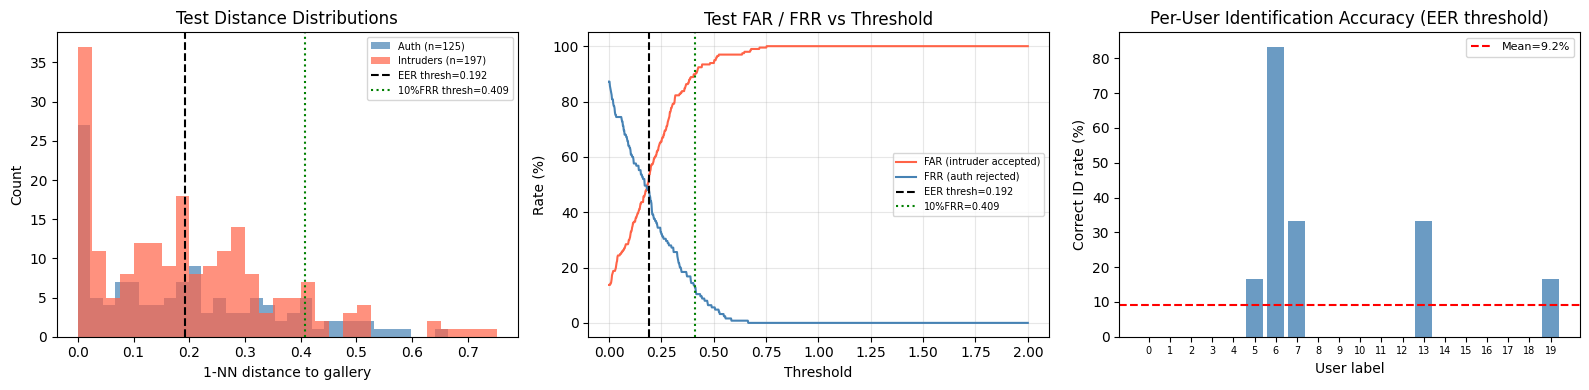


Final Summary:
  Intruder rejection rate (EER threshold) : 46.7%
  Auth acceptance rate   (EER threshold)  : 52.8%
  Identification accuracy (correct name)  : 8.8%


In [12]:
# Visualisation and Final intruder rejection and auth acceptance ratios
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Test distance distributions
axes[0].hist(auth_dists_test,     bins=30, alpha=0.7, color='steelblue', label=f'Auth (n={len(auth_dists_test)})')
axes[0].hist(intruder_dists_test, bins=30, alpha=0.7, color='tomato',    label=f'Intruders (n={len(intruder_dists_test)})')
axes[0].axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.5, label=f'EER thresh={THRESHOLD:.3f}')
axes[0].axvline(THRESHOLD_10FRR, color='green', linestyle=':', linewidth=1.5, label=f'10%FRR thresh={THRESHOLD_10FRR:.3f}')
axes[0].set_xlabel('1-NN distance to gallery'); axes[0].set_ylabel('Count')
axes[0].set_title('Test Distance Distributions'); axes[0].legend(fontsize=7)

# 2. FAR / FRR on test data
ts    = np.linspace(0, 2, 1000)
far_t = np.array([np.mean(intruder_dists_test <= t) for t in ts])
frr_t = np.array([np.mean(auth_dists_test > t)      for t in ts])

axes[1].plot(ts, far_t * 100, color='tomato',    linewidth=1.5, label='FAR (intruder accepted)')
axes[1].plot(ts, frr_t * 100, color='steelblue', linewidth=1.5, label='FRR (auth rejected)')
axes[1].axvline(THRESHOLD, color='black',  linestyle='--', label=f'EER thresh={THRESHOLD:.3f}')
axes[1].axvline(THRESHOLD_10FRR, color='green', linestyle=':', label=f'10%FRR={THRESHOLD_10FRR:.3f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Rate (%)')
axes[1].set_title('Test FAR / FRR vs Threshold'); axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

# 3. Per-user identification accuracy
user_accs = []
for lbl in range(N_REGISTERED):
    mask    = (test_auth_lbls == lbl)
    if not mask.any():
        user_accs.append(0.0); continue
    idxs    = np.where(mask)[0]
    results = [auth_results[i] for i in idxs]
    correct = sum(1 for r_lbl, _, _, st in results if st == 'ACCEPTED' and r_lbl == lbl)
    user_accs.append(correct / len(results) * 100)

x = np.arange(N_REGISTERED)
axes[2].bar(x, user_accs, color='steelblue', alpha=0.8)
axes[2].axhline(np.mean(user_accs), color='red', linestyle='--', label=f'Mean={np.mean(user_accs):.1f}%')
axes[2].set_xticks(x); axes[2].set_xticklabels([str(i) for i in range(N_REGISTERED)], fontsize=7)
axes[2].set_xlabel('User label'); axes[2].set_ylabel('Correct ID rate (%)')
axes[2].set_title('Per-User Identification Accuracy (EER threshold)'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('models/evaluation_v3.png', dpi=150, bbox_inches='tight')
plt.show()

rej_eer_pct = rej_eer / len(intruder_dists_test) * 100
acc_eer_pct = acc_eer / len(auth_dists_test) * 100
print(f'\nFinal Summary:')
print(f'  Intruder rejection rate (EER threshold) : {rej_eer_pct:.1f}%')
print(f'  Auth acceptance rate   (EER threshold)  : {acc_eer_pct:.1f}%')
print(f'  Identification accuracy (correct name)  : {cid_eer / len(auth_dists_test) * 100:.1f}%')